# Implicit Trapezoidal Method for 1D ODE
Solve
$$
\begin{align*}
  y' &= f(t,y)\\
  y(a) &= \alpha\\
\end{align*}
$$
With $a \leq t  \leq b $. The iterative schema is the following:

$$
\begin{align*}
y_0 &= \alpha \\
y_{j+1} &= y_j + \dfrac{h}{2} [f(t_{j+1}, y_{j+1}) + f(t_j, y_j)]
\end{align*}
$$

For $0 \leq j \leq N-1$. Notice that the expression involves *finding* $y_{i+1}$. For this reason, one must solve the following equation at each iteration instead:
$$
g(u) = -u + y_i + \dfrac{h}{2}[f(t_i, y_i) + f(t_{i+1}, u)]
$$

Following Newton-Raphson method, a good guess is the following:
$$u_0 = y_i + h f(t_i, y_i)$$
And proceed as follows
$$
\begin{align*}
u_{k+1} &= u_{k} + \dfrac{g(u_k)}{g'(u_k)} \\
        &= u_k + \dfrac{-u_k + y_i + \dfrac{h}{2}[f(t_i, y_i) + f(t_{i+1}, u_k)]}{-1 + \dfrac{h}{2} \dfrac{\partial f}{\partial y}(t_{i+1}, u_k)}
\end{align*}
$$

### Setting up the example
$$
\begin{align*}
  y' &= 5 e^{5 t}(y-t)^2 +1\\
  y(0) &= -1 \\
\end{align*}
$$
With $0 \leq t  \leq 1$ and $n=5$ discretization points across the time domain.

In [5]:
import numpy as np

def f(t, y):
    return 5 * np.exp(5 * t) * (y - t)**2 + 1

def partialy_f(t, y):
    return 10 * np.exp(5 * t) * (y - t)

N = 20
A = 0
B = 1
ALPHA = -1
H = (B - A) / N
tt = np.linspace(A, B, N)

Implementing Newton-Raphson method solver for this particular example
\begin{align*}
u_{k+1} = u_k + \dfrac{-u_k + y_i + \dfrac{h}{2}[f(t_i, y_i) + f(t_{i+1}, u_k)]}{-1 + \dfrac{h}{2} \dfrac{\partial f}{\partial y}(t_{i+1}, u_k)}
\end{align*}

In [6]:
from typing import Callable

def newton(
        f: Callable,
        fy: Callable,
        ti: float,
        ti_: float,  # t_{i+1}
        y: float,
        iterations: int = 5
) -> float:    
    x = y + H * f(ti, y)
    for _ in range(iterations):
        numerator = -x + y + (.5 * H) * (f(ti, y) + f(ti_, x))
        denominator = -1 + (.5 * H) * (fy(ti_, x))
        x -= numerator/denominator
    return x

Implementing iterative method
$$
\begin{align*}
y_0 &= \alpha \\
y_{j+1} &= y_j + \dfrac{h}{2} [f(t_{j+1}, y_{j+1}) + f(t_j, y_j)]
\end{align*}
$$

In [7]:
def trapezoidal_method(
        f: Callable,
        fy: Callable,
) -> np.ndarray:
    y = np.empty(N, float)
    y[0] = ALPHA
    for i in range(1, N):
        y[i] = newton(f, fy, tt[i-1], tt[i], y[i-1])
    return y


yy = trapezoidal_method(f, partialy_f)

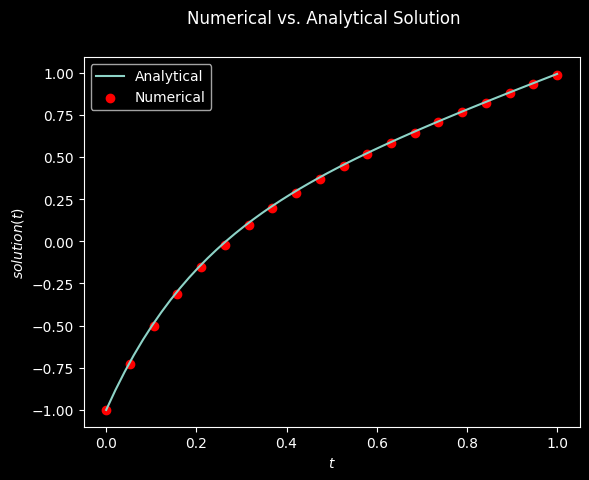

In [8]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

from utils.visualization import continuum_discretized_plot

def solution(t):
    return t - np.exp(-5 * t)

xx = np.linspace(A, B, 50)

fig, ax = continuum_discretized_plot(xx, solution, np.array([tt, yy]))